# 📡 Telecom X Latam — Análisis de Cancelación de Clientes

Telecom X registra una tasa elevada de cancelaciones de clientes. Este análisis busca identificar qué factores están asociados a esa cancelación, usando datos de más de 7.000 clientes.

El proceso sigue la metodología **ETL**:
- **Extracción**: carga de datos desde la API
- **Transformación**: limpieza y preparación del dataset
- **Análisis**: visualizaciones e interpretación de resultados

---
# 📌 1. Extracción

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

C_ACTIVO    = '#2DC653'  # verde — clientes activos
C_CANCELADO = '#E63946'  # rojo  — clientes que cancelaron
PALETTE     = ['#4361EE','#7209B7','#3A0CA3','#560BAD','#480CA8','#3F37C9','#4895EF']

sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 12

print('Librerías cargadas ✅')

Librerías cargadas ✅


Los datos de Telecom X están disponibles en formato JSON a través de una API pública. Los descargamos directamente con Python.

In [2]:
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
response = requests.get(url)
data = response.json()

print(f'Registros recibidos: {len(data)} ✅')

Registros recibidos: 7267 ✅


El JSON viene con estructura anidada (los datos de cada cliente están agrupados en subcategorías). Usamos `json_normalize` para convertirlo en una tabla plana donde cada fila es un cliente y cada columna es una variable.

In [3]:
df = pd.json_normalize(data)

print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
df.head(3)

Dimensiones: 7267 filas x 21 columnas


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


---
# 🔧 2. Transformación

## 2.1 Exploración inicial

Antes de modificar los datos, revisamos su estructura: tipos de variables, nombres de columnas y cantidad de registros.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

## 2.2 Renombre de columnas

Las columnas vienen en inglés y con nombres anidados como `customer, account`. Las traducimos al español con nombres claros y directos.

In [5]:
df.rename(columns={
    'customerID'               : 'id_cliente',
    'Churn'                    : 'cancelacion',
    'customer.gender'          : 'genero',
    'customer.SeniorCitizen'   : 'adulto_mayor',
    'customer.Partner'         : 'tiene_pareja',
    'customer.Dependents'      : 'grupo_familiar',
    'customer.tenure'          : 'meses_contrato',
    'phone.PhoneService'       : 'servicio_telefonico',
    'phone.MultipleLines'      : 'multiples_lineas',
    'internet.InternetService' : 'servicio_internet',
    'internet.OnlineSecurity'  : 'seguridad_online',
    'internet.OnlineBackup'    : 'almacenamiento_nube',
    'internet.DeviceProtection': 'proteccion_dispositivo',
    'internet.TechSupport'     : 'soporte_tecnico',
    'internet.StreamingTV'     : 'streaming_tv',
    'internet.StreamingMovies' : 'streaming_peliculas',
    'account.Contract'         : 'tipo_contrato',
    'account.PaperlessBilling' : 'factura_electronica',
    'account.PaymentMethod'    : 'metodo_pago',
    'account.Charges.Monthly'  : 'cargo_mensual',
    'account.Charges.Total'    : 'cargo_total'
}, inplace=True)

print('Columnas renombradas ✅')
df.head(3)

Columnas renombradas ✅


,id_cliente,cancelacion,genero,adulto_mayor,tiene_pareja,grupo_familiar,meses_contrato,servicio_telefonico,multiples_lineas,servicio_internet,...,almacenamiento_nube,proteccion_dispositivo,soporte_tecnico,streaming_tv,streaming_peliculas,tipo_contrato,factura_electronica,metodo_pago,cargo_mensual,cargo_total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


## 2.3 Verificación de inconsistencias

Revisamos si hay valores nulos, filas duplicadas o datos con formato incorrecto que puedan afectar el análisis.

In [6]:
print('=== Valores nulos por columna ===')
print(df.isnull().sum())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')

=== Valores nulos por columna ===
id_cliente                0
cancelacion               0
genero                    0
adulto_mayor              0
tiene_pareja              0
grupo_familiar            0
meses_contrato            0
servicio_telefonico       0
multiples_lineas          0
servicio_internet         0
seguridad_online          0
almacenamiento_nube       0
proteccion_dispositivo    0
soporte_tecnico           0
streaming_tv              0
streaming_peliculas       0
tipo_contrato             0
factura_electronica       0
metodo_pago               0
cargo_mensual             0
cargo_total               0
dtype: int64

Filas duplicadas: 0


`isnull()` detecta valores vacíos estándar (None, NaN), pero no detecta strings vacíos. Los revisamos por separado ya que Python los trata como texto válido.

In [7]:
vacios_cancelacion = (df['cancelacion'].str.strip() == '').sum()
print(f'Valores únicos en cancelacion:  {df["cancelacion"].unique()}')
print(f'Filas con cancelacion vacía:    {vacios_cancelacion}')

vacios_cargo = (df['cargo_total'].astype(str).str.strip() == '').sum()
print(f'\nTipo de dato cargo_total:       {df["cargo_total"].dtype}')
print(f'Filas con cargo_total vacío:    {vacios_cargo}')

Valores únicos en cancelacion:  ['No' 'Yes' '']
Filas con cancelacion vacía:    224

Tipo de dato cargo_total:       object
Filas con cargo_total vacío:    11


**Inconsistencias detectadas:**
- `cancelacion` tiene filas con texto vacío `''` — no aportan información para el análisis.
- `cargo_total` está almacenado como texto en lugar de número, con algunas filas sin valor — corresponden a clientes sin facturación registrada.
- `adulto_mayor` viene codificado como 0 y 1 en lugar de valores descriptivos.

Los tres casos se corrigen a continuación.

## 2.4 Corrección de inconsistencias

In [8]:
df = df[df['cancelacion'].str.strip() != '']

df['cargo_total'] = pd.to_numeric(df['cargo_total'], errors='coerce')
df = df.dropna(subset=['cargo_total'])

df['adulto_mayor'] = df['adulto_mayor'].map({0: 'No', 1: 'Sí'})

df = df.reset_index(drop=True)

print(f'Registros tras limpieza:     {len(df)}')
print(f'Nulos restantes:             {df.isnull().sum().sum()}')
print(f'Tipo de dato cargo_total:    {df["cargo_total"].dtype}')
print(f'Valores en cancelacion:      {df["cancelacion"].unique()}')
print(f'Valores en adulto_mayor:     {df["adulto_mayor"].unique()}')

Registros tras limpieza:     7032
Nulos restantes:             0
Tipo de dato cargo_total:    float64
Valores en cancelacion:      ['No' 'Yes']
Valores en adulto_mayor:     ['No' 'Sí']


---
# 📊 3. Análisis

## 3.1 Estadísticas descriptivas

Calculamos las métricas básicas de las variables numéricas: media, mediana, desviación estándar y rango. Esto nos da una primera idea de la distribución de los datos antes de profundizar en el análisis.

In [9]:
df[['meses_contrato', 'cargo_mensual', 'cargo_total']].describe().round(2)

,meses_contrato,cargo_mensual,cargo_total
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


In [10]:
for col, nombre in [
    ('meses_contrato', 'Meses de contrato'),
    ('cargo_mensual',  'Cargo mensual ($)'),
    ('cargo_total',    'Cargo total acumulado ($)')
]:
    print(f'\n--- {nombre} ---')
    print(f'  Media:               {df[col].mean():.2f}')
    print(f'  Mediana:             {df[col].median():.2f}')
    print(f'  Desviación estándar: {df[col].std():.2f}')
    print(f'  Rango:               {df[col].min():.0f} — {df[col].max():.0f}')


--- Meses de contrato ---
  Media:               32.42
  Mediana:             29.00
  Desviación estándar: 24.55
  Rango:               1 — 72

--- Cargo mensual ($) ---
  Media:               64.80
  Mediana:             70.35
  Desviación estándar: 30.09
  Rango:               18 — 119

--- Cargo total acumulado ($) ---
  Media:               2283.30
  Mediana:             1397.47
  Desviación estándar: 2266.77
  Rango:               19 — 8685


## 3.2 Distribución de cancelaciones

Antes de analizar los factores asociados, establecemos el punto de partida: cuántos clientes cancelaron el servicio y cuántos siguen activos.

In [11]:
conteo = df['cancelacion'].value_counts()
tasa_global = (df['cancelacion'] == 'Yes').mean() * 100

resumen = pd.DataFrame({
    'Grupo'         : ['Activos', 'Cancelaron'],
    'Cantidad'      : [conteo.get('No', 0), conteo.get('Yes', 0)],
    'Porcentaje (%)': [
        round(conteo.get('No',  0) / len(df) * 100, 1),
        round(conteo.get('Yes', 0) / len(df) * 100, 1)
    ]
})
print(resumen.to_string(index=False))
print(f'\nTotal de clientes: {len(df)}')

     Grupo  Cantidad  Porcentaje (%)
   Activos      5163            73.4
Cancelaron      1869            26.6

Total de clientes: 7032


El gráfico de barras muestra las cantidades absolutas de cada grupo. El gráfico circular muestra la proporción. Verde representa clientes activos, rojo los que cancelaron.

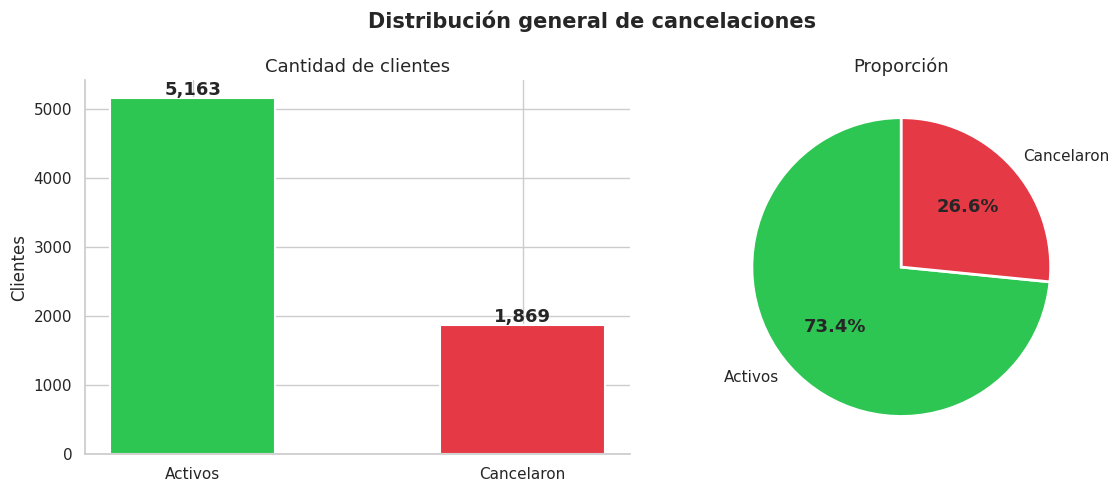

In [12]:
etiquetas = ['Activos', 'Cancelaron']
colores   = [C_ACTIVO, C_CANCELADO]
valores   = [conteo.get('No', 0), conteo.get('Yes', 0)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución general de cancelaciones', fontsize=15, fontweight='bold')

bars = axes[0].bar(etiquetas, valores, color=colores, edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Cantidad de clientes', fontsize=13)
axes[0].set_ylabel('Clientes')
axes[0].spines[['top','right']].set_visible(False)
for bar, val in zip(bars, valores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=13)

wedges, texts, autotexts = axes[1].pie(
    valores, labels=etiquetas, autopct='%1.1f%%',
    colors=colores, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for t in autotexts:
    t.set_fontsize(13)
    t.set_fontweight('bold')
axes[1].set_title('Proporción', fontsize=13)

plt.tight_layout()
plt.show()

## 3.3 Cancelaciones por variables categóricas

Analizamos la tasa de cancelación según características del cliente. Se incluyen solo las variables donde la diferencia entre grupos supera los 5 puntos porcentuales, lo que indica una relación relevante con la cancelación.

La línea punteada roja marca la tasa global. Las barras en rojo superan ese umbral — son los grupos con mayor riesgo. Las barras en azul están por debajo.

In [13]:
def tasa_cancelacion_por(df, columna):
    tabla = df.groupby(columna)['cancelacion'].apply(
        lambda x: (x == 'Yes').sum() / len(x) * 100
    ).reset_index()
    tabla.columns = [columna, 'tasa (%)']
    return tabla.sort_values('tasa (%)', ascending=False).round(1)

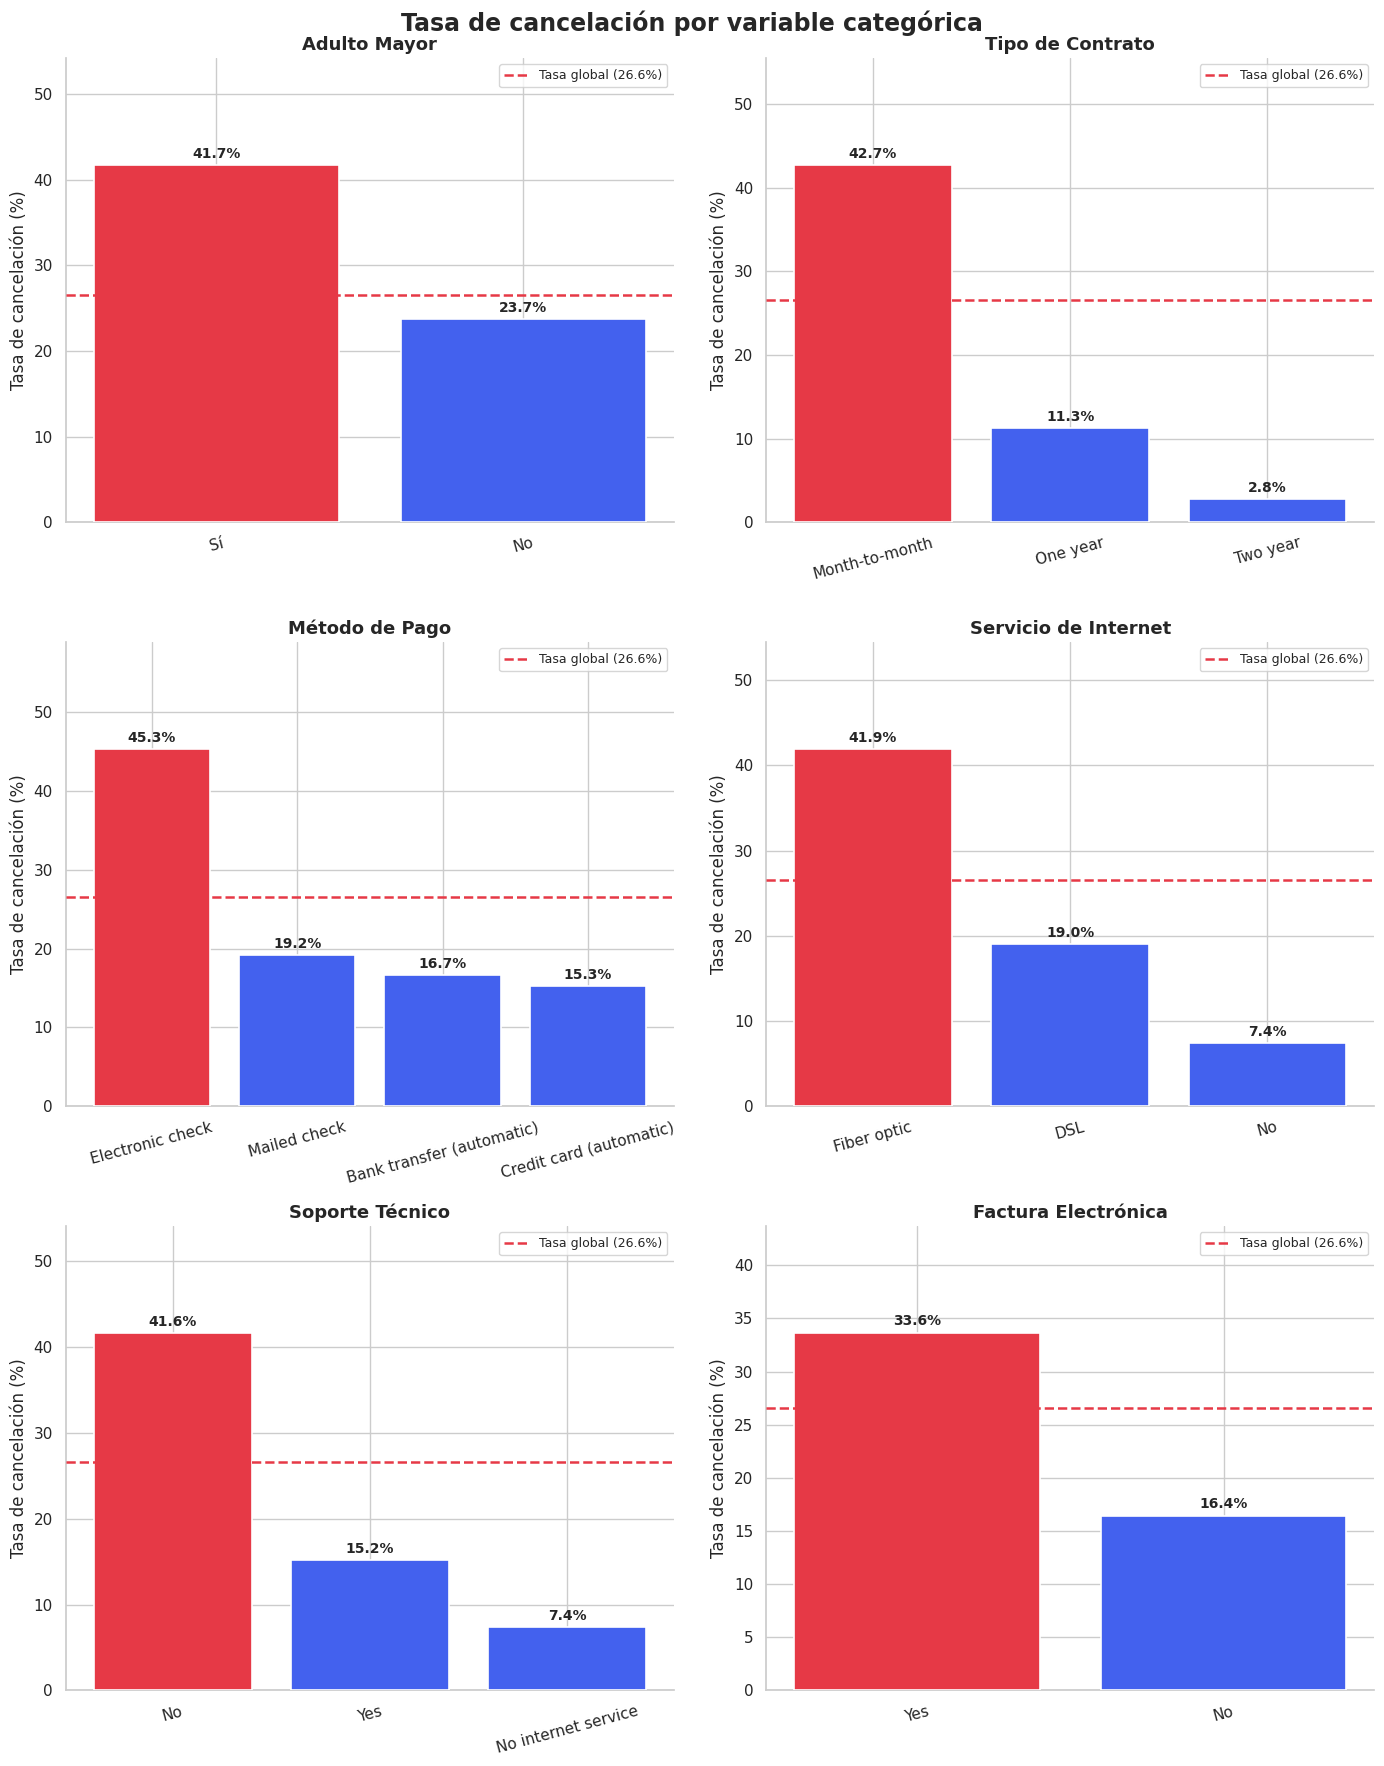

In [14]:
variables_cat = [
    ('adulto_mayor',      'Adulto Mayor'),
    ('tipo_contrato',     'Tipo de Contrato'),
    ('metodo_pago',       'Método de Pago'),
    ('servicio_internet', 'Servicio de Internet'),
    ('soporte_tecnico',   'Soporte Técnico'),
    ('factura_electronica', 'Factura Electrónica')
]

fig, axes = plt.subplots(3, 2, figsize=(14, 18))
axes = axes.flatten()

for i, (col, titulo) in enumerate(variables_cat):
    tabla = tasa_cancelacion_por(df, col)
    colores_barra = [C_CANCELADO if v > tasa_global else '#4361EE' for v in tabla['tasa (%)']]

    bars = axes[i].bar(
        tabla[col].astype(str), tabla['tasa (%)'],
        color=colores_barra, edgecolor='white', linewidth=1.2, zorder=3
    )
    axes[i].axhline(tasa_global, color='#E63946', linewidth=1.8,
                    linestyle='--', label=f'Tasa global ({tasa_global:.1f}%)', zorder=4)
    axes[i].set_title(titulo, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Tasa de cancelación (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=15)
    axes[i].set_ylim(0, tabla['tasa (%)'].max() * 1.3)
    axes[i].spines[['top','right']].set_visible(False)
    axes[i].legend(fontsize=9)

    for bar, val in zip(bars, tabla['tasa (%)']):
        axes[i].text(
            bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold'
        )

fig.suptitle('Tasa de cancelación por variable categórica', fontsize=17, fontweight='bold')
plt.tight_layout()
plt.show()

**Lectura de los resultados:**
- **Tipo de contrato**: los clientes con contrato mensual cancelan al 42.7%, los de dos años al 2.8%. Es la variable con mayor impacto.
- **Método de pago**: el cheque electrónico tiene la tasa más alta (45.3%). Los métodos automáticos (tarjeta, transferencia) están todos por debajo del 17%.
- **Servicio de internet**: los clientes con fibra óptica cancelan al 41.9% vs 19% los de DSL.
- **Soporte técnico**: sin soporte, la tasa es 41.6%. Con soporte, baja al 15.2%.
- **Adulto mayor**: los adultos mayores cancelan al 41.7% vs 23.7% el resto.
- **Factura electrónica**: los clientes con factura en papel cancelan menos (16.4% vs 33.6%).

## 3.4 Cancelaciones por variables numéricas

Comparamos la distribución de las variables numéricas entre clientes activos y cancelados. El histograma muestra la frecuencia de cada valor y la curva suave (KDE) indica la tendencia general de cada grupo. Cuando las curvas se separan, esa variable tiene relación con la cancelación.

🟢 Verde = Activos · 🔴 Rojo = Cancelaron

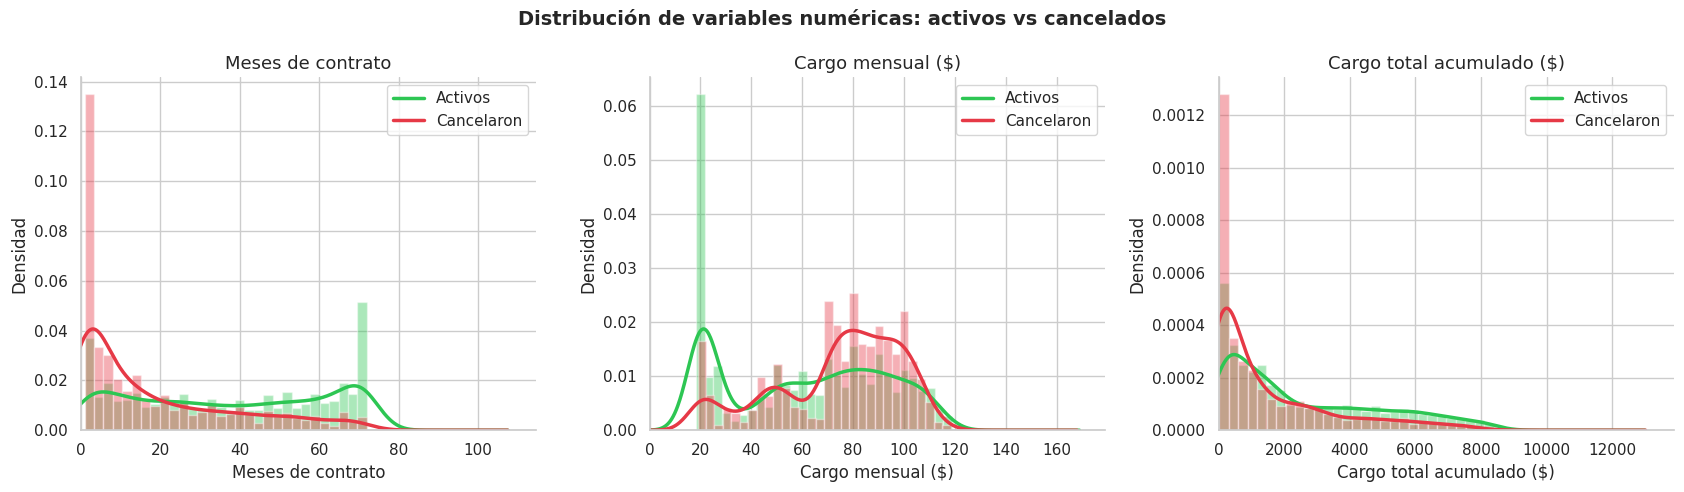

In [15]:
variables_num = [
    ('meses_contrato', 'Meses de contrato'),
    ('cargo_mensual',  'Cargo mensual ($)'),
    ('cargo_total',    'Cargo total acumulado ($)')
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Distribución de variables numéricas: activos vs cancelados', fontsize=14, fontweight='bold')

for i, (col, titulo) in enumerate(variables_num):
    for label, color, nombre in [('No', C_ACTIVO, 'Activos'), ('Yes', C_CANCELADO, 'Cancelaron')]:
        subset = df[df['cancelacion'] == label][col]
        axes[i].hist(subset, bins=30, alpha=0.4, color=color, edgecolor='white', density=True)
        subset.plot.kde(ax=axes[i], color=color, linewidth=2.5, label=nombre)

    axes[i].set_title(titulo, fontsize=13)
    axes[i].set_xlabel(titulo)
    axes[i].set_ylabel('Densidad')
    axes[i].set_xlim(left=0)
    axes[i].spines[['top','right']].set_visible(False)
    axes[i].legend()

plt.tight_layout()
plt.show()

**Lectura de los resultados:**
- **Meses de contrato**: los cancelados tienen el pico en los primeros meses (curva roja concentrada al inicio). Los activos están distribuidos a lo largo del tiempo.
- **Cargo mensual**: los cancelados tienden a pagar más por mes. La curva roja está desplazada hacia la derecha respecto a la verde.
- **Cargo total acumulado**: los cancelados acumularon poco antes de irse — se fueron antes de generar valor económico significativo para la empresa. Los activos, al llevar más tiempo, acumularon montos mucho mayores.

### Medianas por grupo

La mediana es más representativa que el promedio cuando hay valores extremos. Comparamos los tres indicadores numéricos entre activos y cancelados.

In [16]:
medianas = df.groupby('cancelacion')[['meses_contrato','cargo_mensual','cargo_total']].median().round(2)
medianas.index = ['Activos', 'Cancelaron']
medianas.columns = ['Meses de contrato', 'Cargo mensual ($)', 'Cargo total acumulado ($)']
print(medianas.to_string())

            Meses de contrato  Cargo mensual ($)  Cargo total acumulado ($)
Activos                  38.0              64.45                    1683.60
Cancelaron               10.0              79.65                     703.55


### Cancelación según antigüedad del cliente

Dividimos a los clientes en tramos de antigüedad para ver en qué momento del ciclo de vida ocurren más cancelaciones.

In [17]:
df['tramo_antiguedad'] = pd.cut(
    df['meses_contrato'],
    bins=[0,6,12,24,36,48,60,72],
    labels=['0-6 meses','6-12 meses','12-24 meses','24-36 meses','36-48 meses','48-60 meses','60-72 meses']
)

tabla_tramos = df.groupby('tramo_antiguedad', observed=True).agg(
    Clientes   = ('cancelacion', 'count'),
    Cancelaron = ('cancelacion', lambda x: (x=='Yes').sum()),
    Tasa       = ('cancelacion', lambda x: round((x=='Yes').sum()/len(x)*100,1))
)
tabla_tramos.columns = ['Total clientes', 'Cancelaron', 'Tasa de cancelación (%)']
print(tabla_tramos.to_string())

                  Total clientes  Cancelaron  Tasa de cancelación (%)
tramo_antiguedad                                                     
0-6 meses                   1470         784                     53.3
6-12 meses                   705         253                     35.9
12-24 meses                 1024         294                     28.7
24-36 meses                  832         180                     21.6
36-48 meses                  762         145                     19.0
48-60 meses                  832         120                     14.4
60-72 meses                 1407          93                      6.6


Las barras muestran la tasa de cancelación para cada tramo de antigüedad. Rojo indica que el tramo supera la tasa global, verde que está por debajo.

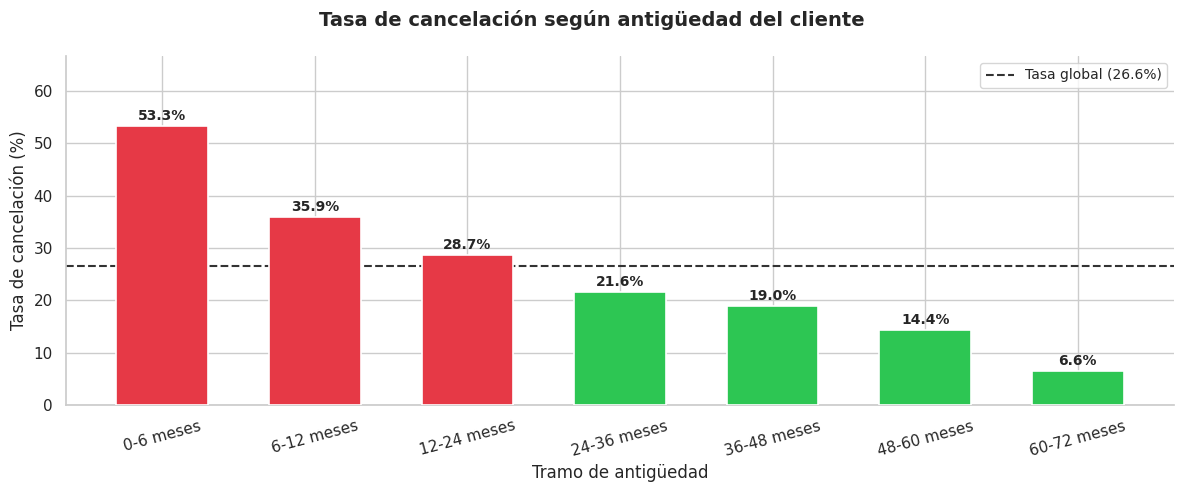

In [18]:
tramos = tabla_tramos.index.astype(str)
tasas  = tabla_tramos['Tasa de cancelación (%)']
colores_tramo = [C_CANCELADO if t > tasa_global else C_ACTIVO for t in tasas]

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Tasa de cancelación según antigüedad del cliente', fontsize=14, fontweight='bold')

bars = ax.bar(tramos, tasas, color=colores_tramo, edgecolor='white', linewidth=1.2, width=0.6, zorder=3)
ax.axhline(tasa_global, color='#333333', linewidth=1.5, linestyle='--', label=f'Tasa global ({tasa_global:.1f}%)')
ax.set_ylabel('Tasa de cancelación (%)')
ax.set_xlabel('Tramo de antigüedad')
ax.set_ylim(0, tasas.max() * 1.25)
ax.spines[['top','right']].set_visible(False)
ax.tick_params(axis='x', rotation=15)
ax.legend(fontsize=10)

for bar, val in zip(bars, tasas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

**Lectura de los resultados:**
- En los primeros 6 meses, 1 de cada 2 clientes cancela (53.3%).
- La tasa cae de forma sostenida con el tiempo: a partir de los 24 meses ya está por debajo de la tasa global.
- Los clientes que llegan a los 60-72 meses cancelan solo el 6.6%.
- Los primeros 12 meses son el período crítico: concentran la mayor parte del riesgo de cancelación.

---
# 📄 4. Informe Final

## Introducción

Este análisis fue realizado sobre datos de clientes de Telecom X con el objetivo de identificar qué factores están asociados a la cancelación del servicio. Se trabajó con un dataset de más de 7.000 clientes, aplicando la metodología ETL: extracción desde una API, limpieza y transformación de los datos, y análisis exploratorio con visualizaciones.

---

## Limpieza y tratamiento de los datos

Se detectaron tres inconsistencias en el dataset original:

- La columna `cancelacion` tenía filas con texto vacío — se eliminaron por no aportar información.
- La columna `cargo_total` estaba almacenada como texto en lugar de número, con algunas filas sin valor — se convirtió a numérico y se eliminaron las filas vacías.
- La columna `adulto_mayor` venía codificada como 0 y 1 — se convirtió a 'No' y 'Sí' para mayor claridad.

No se encontraron filas duplicadas. El dataset final quedó con:

In [19]:
print(f'{len(df)} registros listos para el análisis.')

7032 registros listos para el análisis.


---

## Análisis exploratorio

### Tasa de cancelación global

In [20]:
tasa  = (df['cancelacion'] == 'Yes').mean() * 100
total = (df['cancelacion'] == 'Yes').sum()
print(f'{tasa:.1f}% de los clientes cancelaron el servicio ({total} de {len(df)}).')

26.6% de los clientes cancelaron el servicio (1869 de 7032).


### Variables con mayor asociación a la cancelación

**Tipo de contrato** — Los clientes con contrato mensual cancelan al 42.7%, los de un año al 11.3% y los de dos años al 2.8%. A mayor duración del compromiso, menor tasa de cancelación.

**Antigüedad** — el 53.3% de los clientes en sus primeros 6 meses cancela el servicio. La tasa cae de forma sostenida hasta el 6.6% en clientes de más de 5 años. Los primeros 12 meses concentran el mayor riesgo.

**Método de pago** — el cheque electrónico registra la tasa más alta (45.3%). Los métodos de pago automáticos (tarjeta de crédito y transferencia bancaria) están por debajo del 17%.

**Servicio de internet** — los clientes con fibra óptica cancelan al 41.9%, más del doble que los de DSL (19%). Los clientes sin servicio de internet cancelan solo el 7.4%.

**Soporte técnico** — los clientes sin soporte técnico cancelan al 41.6%. Los que lo tienen contratado cancelan al 15.2%.


---

## Conclusiones e insights

Los datos muestran un patrón claro: la cancelación no es aleatoria. Está concentrada en clientes nuevos, con contratos de corto plazo y que pagan con métodos no automáticos.

El cliente con mayor riesgo de cancelación tiene estas características: lleva menos de 6 meses, tiene contrato mensual, paga con cheque electrónico y no tiene soporte técnico ni fibra óptica de buena calidad.

---

## Recomendaciones

- **Incentivar contratos anuales o bianuales**: la diferencia en tasa de cancelación entre un contrato mensual (42.7%) y uno de dos años (2.8%) es de 40 puntos porcentuales.
- **Priorizar la retención en los primeros 12 meses**: más de la mitad de los clientes nuevos cancela en ese período. Acciones de seguimiento y soporte en esa etapa pueden reducir significativamente la tasa global.
- **Revisar la calidad del servicio de fibra óptica**: tiene la tasa de cancelación más alta del dataset a pesar de ser el servicio de mayor costo.
- **Incluir soporte técnico en más planes**: reduce la tasa de cancelación en más de 26 puntos porcentuales respecto a los clientes que no lo tienen.
- **Promover métodos de pago automáticos**: están asociados a tasas de cancelación por debajo del 17%, frente al 45.3% del cheque electrónico.